# **SPECTRA v2**

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import torch
import json
import networkx as nx
from matplotlib import pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
from torch_geometric.utils import from_networkx
import os

import warnings
warnings.filterwarnings("ignore")

/scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


In [3]:
# torch device setting
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(torch.version.cuda)
    print(torch.cuda.get_device_name())
else:
    device = torch.device('cpu')
print(device)

12.1
Tesla V100-SXM2-32GB
cuda


In [4]:
import wandb
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/michele.calabro/.netrc.
wandb: Currently logged in as: michi-geco97 (michi-geco97-politecn) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [6]:
# here we put all the hyperparameters, metadata and stuff
config = dict(
    dataset_size=170000,
    test_ratio=0.2,
    val_ratio=0.1,
    batch_size=48,
    n_channels=24,
    edge_dropout_p=0.0001,
    lr=0.001,
    n_epochs=20,
    dataset="VCC",
    architecture="SageConv_new")

In [7]:
# Initialize wandb run
wandb.init(
    project="spectra-v2",       # The name of your project in wandb
    name="full_WMMD_SAGEConv_3mar",   # (Optional) Name of this specific run
    config=config               # Pass your dictionary here!
)

### **Data import**

In [8]:
# data loading and filtering
adata = sc.read_h5ad('../data/vcc_data/adata_Training.h5ad') #VCC
#adata = sc.read_h5ad('../data/replogle_k562_essential/perturb_processed.h5ad') # replogle
adata

AnnData object with n_obs × n_vars = 221273 × 18080
    obs: 'target_gene', 'guide_id', 'batch'
    var: 'gene_id'

In [ ]:
# Rename column and ctrl samples
adata.obs = adata.obs.rename(columns={"condition": "target_gene"})
adata.obs["target_gene"] = adata.obs["target_gene"].str.replace("ctrl", "non-targeting", regex=False)

# rename of single perturbations
adata.obs["target_gene"] = adata.obs["target_gene"].str.replace("ctrl", "non-targeting", regex=False)
adata.obs['target_gene'] = adata.obs['target_gene'].str.replace(r'\+non-targeting$', '', regex=True)

adata

AnnData object with n_obs × n_vars = 162751 × 5000
    obs: 'target_gene', 'cell_type', 'cov_drug_dose_name', 'dose_val', 'control', 'condition_name'
    var: 'gene_name', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'non_dropout_gene_idx', 'non_zeros_gene_idx', 'rank_genes_groups_cov_all', 'top_non_dropout_de_20', 'top_non_zero_de_20'

In [9]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3) # TODO: should be 3 but if so I would have to recalculate the GRN....
adata

AnnData object with n_obs × n_vars = 221273 × 18020
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'

In [10]:
adata.raw = adata.copy() 
sc.pp.normalize_total(adata, target_sum = 1e4)
sc.pp.log1p(adata)

# select only perturbations that are present in at least 200 cells
counts = adata.obs['target_gene'].value_counts()
valid_pert = counts[counts >= 100].index
adata = adata[adata.obs['target_gene'].isin(valid_pert)]
del counts
del valid_pert
adata

View of AnnData object with n_obs × n_vars = 220998 × 18020
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

### **GRN preparation**

***
### Patrick stuff

In [11]:
# patrick guanlab (stock)
A = np.load('Patrick_networks/guanlab_stock_3.5k_directed.npz')
adjacency = A['adjacency']
gene_names = A['gene_names']

# Create weighted DiGraph (parallel_edges=False treats values as weights)
G = nx.from_numpy_array(
    adjacency,
    parallel_edges=False,
    create_using=nx.DiGraph(),
    edge_attr='weight',  # Attribute name for weights
)

# Relabel nodes with gene names (must be same length as matrix dims)
mapping = {i: gene_names[i] for i in range(len(gene_names))}
G = nx.relabel_nodes(G, mapping)

# naive pruning
G.remove_edges_from([(u, v) for u, v, d in G.edges(data=True) if np.log(d['weight']+1) < 8])

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
num_features = 1
print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)
print("Number of node features per node:", num_features)

# filter adata
gene_list = gene_names.tolist()
mask = adata.var_names.isin(gene_names)
adata = adata[:, mask].copy()
adata

Number of nodes: 3406
Number of edges: 474761
Number of node features per node: 1


AnnData object with n_obs × n_vars = 220998 × 3406
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

### End of patrick stuff
***

In [ ]:
# replogle grn

# network file
with open('../SCENIC_GRNs/SCENIC_GRNs/networks/repogle_network.json', 'r') as json_file:
    network = json.load(json_file)
    
# Create the networkx graph
G = nx.DiGraph()
for tf, targets in network.items():
    for target, weight in targets:
        G.add_edge(tf, target, weight=weight)

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
num_features = 1
gene_list = list(G.nodes)

print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)
print("Number of node features per node:", num_features)

# filtering data to gene contained in the network G
adata.var_names = adata.var['gene_name'].astype(str)
adata.var_names_make_unique()
adata = adata[:, adata.var_names.isin(gene_list)]

# perturbation filtering
perturbations = list(adata.obs['target_gene'].unique())
perturbations.remove('non-targeting')
perts_not_included = [pert for pert in perturbations if not pert in gene_list]
adata = adata[~adata.obs['target_gene'].isin(perts_not_included)].copy()

# adata rows shuffle (otherwise perturbations are all ordered)
adata = adata[np.random.permutation(adata.n_obs), :].copy()
adata

Number of nodes: 3390
Number of edges: 11995
Number of node features per node: 1


AnnData object with n_obs × n_vars = 52525 × 3390
    obs: 'target_gene', 'cell_type', 'cov_drug_dose_name', 'dose_val', 'control', 'condition_name'
    var: 'gene_name', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'non_dropout_gene_idx', 'non_zeros_gene_idx', 'rank_genes_groups_cov_all', 'top_non_dropout_de_20', 'top_non_zero_de_20'

***

### GRNBoost2 network on 3406 genes

In [ ]:
# load GRN
network_data = pd.read_csv('../SCENIC_GRNs/SCENIC_GRNs/temp_results/adjacencies_vcc_3406.tsv', sep='\t')

# Create the networkx graph
G = nx.DiGraph()
for i in range(network_data.shape[0]):
    edge = network_data.iloc[i,:]
    if np.abs(edge['importance'])>0.0: #TODO: dumb pruning, make somehting better please
        G.add_edge(edge['TF'], edge['target'], weight=edge['importance'])

gene_list = list(G.nodes)

mask = adata.var_names.isin(gene_list)
adata = adata[:, mask].copy()
adata

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)

Number of nodes: 3391
Number of edges: 213388


***

In [12]:
# check if the node names of th enwtrokx graph aorresponds to adata.var_names
assert set(G.nodes) == set(adata.var_names), "Nodes in G and adata.var_names differ!"

In [13]:
# relabel networkx node indices to match the adata
gene_to_idx = {node: i for i, node in enumerate(adata.var_names)}
G = nx.relabel_nodes(G, gene_to_idx)
edge_index = from_networkx(G, group_edge_attrs='all').edge_index # this way, edge_index follows the gene order of adata.var_names

### **Dataloaders preparation**
Compared with the original SPECTRA model, here we should calculate the dataloaders so that in each batch there are only samples taken from the same perturbations.

In [14]:
from torch.utils.data.sampler import Sampler
import random

# a special batch sampler that groups only cells from the same interventional distribution into a batch
class SCDATA_sampler(Sampler):
    def __init__(self, data, batchsize, ptb_name=None):
        self.intervindices = []
        self.len = 0
        if ptb_name is None:
            ptb_name = data.ptb_names

        for ptb in set(ptb_name):
            idx = np.where(ptb_name == ptb)[0] # indices of cells with the same pert ptb
            self.intervindices.append(idx) # list of indices of cells with the same pert ptb
            self.len += len(idx) // batchsize # number of batches with pert ptb
        self.batchsize = batchsize
    
    def __iter__(self):
        comb = []
        # loop over each intervention
        for i in range(len(self.intervindices)):
            random.shuffle(self.intervindices[i]) # intra-Perturbation Shuffle
            interv_batches = chunk(self.intervindices[i], self.batchsize)
            if interv_batches:
                comb += interv_batches

        combined = [batch.tolist() for batch in comb]
        random.shuffle(combined) # shuffle the order of the batches
        return iter(combined)

    def __len__(self):
        return self.len


def chunk(indices, chunk_size):
    split = torch.split(torch.tensor(indices), chunk_size) # this divides the torch indices into subsets of equal length chunk_size
    
    if len(indices) % chunk_size == 0:
        return split
    elif len(split) > 0:
        # If there are some indices left over (the last chunk is smaller than chunk_size),
        # this line discards the last chunk. 
        # It returns all the chunks except the last one.
        return split[:-1]
    else:
        return None

In [15]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class PerturbationDataset(Dataset):
    def __init__(self, adata, gene_to_idx, start_idx=0, end_idx=None, seed=42):
        super().__init__()

        self.edge_index = edge_index.share_memory_()
        self.gene_to_idx = gene_to_idx
        self.start_idx = start_idx
        self.seed = seed
        self.end_idx = end_idx if end_idx is not None else len(adata)

        adata = adata[self.start_idx:self.end_idx].copy()
        self.adata = adata

        # perturbed samples
        ptb_adata = adata[adata.obs['target_gene']!='non-targeting'].copy()
        ptb_samples = ptb_adata.X.toarray() if hasattr(ptb_adata.X, 'toarray') else np.asarray(ptb_adata.X)
        self.ptb_samples = torch.tensor(ptb_samples, dtype=torch.float) #NOTE: local to this split
        self.ptb_names = ptb_adata.obs['target_gene'].values #NOTE: local to this split

        # control samples
        self.ctrl_samples = adata[adata.obs['target_gene']=='non-targeting'].X.copy()
        self.ctrl_samples = self.ctrl_samples.toarray() if hasattr(self.ctrl_samples, 'toarray') else np.asarray(self.ctrl_samples)
        self.ctrl_samples = torch.tensor(self.ctrl_samples, dtype=torch.float)

    def _pert_embedding(self, pert_name):
        embedding = torch.zeros(self.adata.shape[1], dtype=torch.bool)
        perturbs = [self.gene_to_idx[g] for g in pert_name.split('+') if g in self.gene_to_idx]
        for pert in perturbs:
            embedding[pert]=True
        return embedding

    def __getitem__(self, idx):
        
        # Map to actual index in adata
        actual_idx = idx

        #x = self.rand_ctrl_samples[actual_idx].view(-1,1)
        j = np.random.randint(0, self.ctrl_samples.shape[0]) #random control cell
        x = self.ctrl_samples[j].view(-1,1)
        y = self.ptb_samples[actual_idx].view(-1,1)
        pert = self._pert_embedding(self.ptb_names[actual_idx])

        return x,y,pert

    def __len__(self):
        return self.ptb_samples.shape[0]

In [16]:
#TODO: add sanity check for dataset_size (must be inferior than the number of the perturbed cells, see how the sampling works)

# Setup
dataset_size = (adata.obs['target_gene'] != 'non-targeting').sum() 
test_ratio = config['test_ratio']
val_ratio = config['val_ratio']
test_size = int(dataset_size * test_ratio)
val_size = int(dataset_size * val_ratio)
train_size = dataset_size - test_size - val_size


# Create datasets
train_dataset = PerturbationDataset(
    adata, gene_to_idx,
    start_idx=0, 
    end_idx=train_size
)

val_dataset = PerturbationDataset(
    adata, gene_to_idx,
    start_idx=train_size, 
    end_idx=train_size+val_size
)

test_dataset = PerturbationDataset(
    adata, gene_to_idx,
    start_idx=train_size+val_size, 
    end_idx=dataset_size
)

N_WORKERS = 4 #TODO this will be passed as an argument to training load dataset
batch_size = config['batch_size']

# create loaders
train_loader = DataLoader(train_dataset, batch_sampler=SCDATA_sampler(train_dataset, batch_size), num_workers=N_WORKERS, pin_memory=True) #pin memory optimize transfer to CUDA
val_loader = DataLoader(val_dataset, batch_sampler=SCDATA_sampler(val_dataset, batch_size), num_workers=N_WORKERS, pin_memory=True) 
test_loader = DataLoader(test_dataset, batch_sampler=SCDATA_sampler(test_dataset, batch_size), num_workers=N_WORKERS, pin_memory=True) 

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

Train dataset size: 105784
Test dataset size: 30241
Validation dataset size: 15125


**NOTES** about dimensions: `pert` has dimension [B,N], `x` and `y` have dimension [B,N,1]

In [17]:
#NOTE: new DEGs weights
from WMSE import compute_weights

gene_weights = compute_weights(adata[0:train_size,:], gene_to_idx, cells_per_pert=256)

Calculating WMSE Weights: 100%|██████████| 145/145 [00:00<00:00, 1686.87it/s]


### **Model setup**

In [18]:
from spectra_v2 import PerturbModel

model = PerturbModel(
    edge_index, 
    num_nodes, 
    device, 
    gene_weights=gene_weights, 
    num_node_features=1, 
    n_channels=config['n_channels'], 
    edge_dropout_p=config['edge_dropout_p']
)
model = model.to(device)
print(model)

PerturbModel(
  (ko_mu): Embedding(3406, 64)
  (ko_mlp): MLP(
    (network): Sequential(
      (0): Dropout(p=0.2, inplace=False)
      (1): Linear(in_features=64, out_features=24, bias=True)
      (2): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): ReLU()
      (4): Dropout(p=0.2, inplace=False)
      (5): Linear(in_features=24, out_features=24, bias=True)
      (6): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (encoder): VariationalGraphEncoder(
    (conv1): DirGNNConv(SAGEConv(1, 24, aggr=mean), alpha=0.5)
    (ln1): LayerNorm((24,), eps=1e-05, elementwise_affine=True)
    (conv2): DirGNNConv(SAGEConv(24, 48, aggr=mean), alpha=0.5)
    (ln2): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
    (conv_mu): DirGNNConv(SAGEConv(48, 24, aggr=mean), alpha=0.5)
    (conv_logstd): DirGNNConv(SAGEConv(48, 24, aggr=mean), alpha=0.5)
  )
  (gex_decoder): FeatureDecoder(
    (conv1): DirGNNConv(SAGEC

In [19]:
num_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'number of parameters: {num_trainable_params}')

number of parameters: 253049


In [20]:
#from model_v3_efficient import train
from spectra_v2 import train
_, _, test_wmse = train(model=model, 
    train_loader=train_loader, 
    test_loader=val_loader,
    lr=config['lr'], 
    n_epochs=config['n_epochs'],  
    device=device,
    wandb_support=True,
    live_plot=False)

training at epoch 1: 100%|██████████| 2133/2133 [25:06<00:00,  1.42it/s]


training KL = 1.23075 | mse = 0.036 | cos = 0.879


training at epoch 2: 100%|██████████| 2133/2133 [24:52<00:00,  1.43it/s]


training KL = 0.94699 | mse = 0.016 | cos = 0.856


training at epoch 3: 100%|██████████| 2133/2133 [24:52<00:00,  1.43it/s]


...

training at epoch 4: 100%|██████████| 2133/2133 [24:52<00:00,  1.43it/s]


training KL = 0.70753 | mse = 0.012 | cos = 0.851


training at epoch 5: 100%|██████████| 2133/2133 [24:52<00:00,  1.43it/s]


training KL = 0.63708 | mse = 0.011 | cos = 0.850


training at epoch 6:  46%|████▋     | 987/2133 [11:30<13:27,  1.42it/s]

In [ ]:
wandb.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/cosine_loss,▁▇██████▇█▇█▇█▇█▇▇▇▇
train/global_loss,█▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁
train/kl_divergence,█▄▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▂▁▁
train/mmd_ctrl,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/mmd_pert,█▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/mse,█▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/test_wmse,▁▁▂▃▂▁▄▃▃▃▆▅▅▃▄▃▃███
epoch,20
train/cosine_loss,0.97589
train/global_loss,0.24066


In [ ]:
torch.save(model.state_dict(), "test_25_gen.pth")

***

### **Testing**

In [ ]:
model.load_state_dict(torch.load("weights/temp_weights_epoch_5.pth"))

/localscratch/31748299.michele.calabro/ipykernel_3069402/3926470866.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("weights/temp_weight

<All keys matched successfully>

In [ ]:
model.eval()

PerturbModel(
  (ko_mu): Embedding(3406, 24)
  (ko_sigma): Embedding(3406, 24)
  (encoder): VariationalGraphEncoder(
    (conv1): DirGNNConv(SAGEConv(1, 24, aggr=mean), alpha=0.5)
    (ln1): LayerNorm((24,), eps=1e-05, elementwise_affine=True)
    (conv2): DirGNNConv(SAGEConv(24, 48, aggr=mean), alpha=0.5)
    (ln2): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
    (conv_mu): DirGNNConv(SAGEConv(48, 24, aggr=mean), alpha=0.5)
    (conv_logstd): DirGNNConv(SAGEConv(48, 24, aggr=mean), alpha=0.5)
  )
  (gex_decoder): FeatureDecoder(
    (conv1): DirGNNConv(SAGEConv(24, 24, aggr=mean), alpha=0.5)
    (ln1): LayerNorm((24,), eps=1e-05, elementwise_affine=True)
    (conv2): DirGNNConv(SAGEConv(24, 24, aggr=mean), alpha=0.5)
    (ln2): LayerNorm((24,), eps=1e-05, elementwise_affine=True)
    (last_layer): Linear(in_features=24, out_features=1, bias=True)
  )
)

In [ ]:
from tqdm import tqdm
from scipy import sparse
import anndata as ad

In [ ]:
# technical duplicates
indices_1 = []
indices_2 = []
for gene, idx in adata.obs.groupby("target_gene").indices.items():
    idx = np.array(idx) # list of indices associated to gene
    half = len(idx) // 2
    indices_1.extend(idx[:half])
    indices_2.extend(idx[half:])
real_adata = adata[indices_1].copy()
pred_adata = adata[indices_2].copy()


/localscratch/29440558.michele.calabro/ipykernel_878365/8321379.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for gene, idx in adata.obs.groupby("target_gene").indices.items():


In [ ]:
n_cells = len(test_dataset)
real_adata = adata[-n_cells:, :]
real_adata

View of AnnData object with n_obs × n_vars = 16503 × 3406
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

In [ ]:
counts = real_adata.obs['target_gene'].value_counts()
valid_pert = counts[counts >= 100].index
real_adata = real_adata[real_adata.obs['target_gene'].isin(valid_pert)]
real_adata

View of AnnData object with n_obs × n_vars = 11638 × 3406
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

In [ ]:
# creation of dict: for each pertuyrbation how many cells to generate
counts = real_adata.obs['target_gene'].value_counts()
counts = counts[counts >= 100]
gene_counts_dict = counts.drop('non-targeting').to_dict()
#gene_counts_dict = counts.to_dict()

In [ ]:
###### NO TSNE
def generate_adata_from_control(gene_counts_dict, real_adata, model, gene_to_idx, var_names):

    prediction_list = []
    obs_gene_list = []

    # ctrl
    real_adata_control = real_adata[real_adata.obs['target_gene']=='non-targeting']
    ctrl_data = real_adata_control.X.toarray() if hasattr(real_adata_control.X, "toarray") else np.asarray(real_adata_control.X)
    ctrl_data = torch.tensor(ctrl_data, dtype=torch.float)

    for pert, n_samples in tqdm(gene_counts_dict.items()):

        # perturbation one-hot embedding
        pert_embedding = torch.zeros(adata.shape[1], dtype=torch.bool)
        if pert!='non-targeting':
            perturbs = [gene_to_idx[g] for g in pert.split('+') if g in gene_to_idx] #NOTE: this takes into account multi-genes pertrurbations
            for single_pert in perturbs:
                pert_embedding[single_pert]=True
            pert_embedding = pert_embedding.unsqueeze(0)
            
        for i in range(n_samples):
            ctrl_sample = ctrl_data[np.random.randint(0, ctrl_data.shape[0], 1), :].reshape(-1,1).unsqueeze(0)
            data = ctrl_sample, pert_embedding
            predicted_full_gex= model.predict_full_expression(data)
            predicted_full_gex = predicted_full_gex.reshape(1,-1).detach().cpu()
            prediction_list.append(predicted_full_gex.numpy()) 
            obs_gene_list.append(pert)

    X = np.vstack(prediction_list)
    obs = pd.DataFrame({"target_gene": obs_gene_list})
    var = pd.DataFrame(index=var_names)
    pred_adata = ad.AnnData(X=X, obs=obs, var=var)
    
    return pred_adata

In [ ]:
####### with TSNE
from sklearn.manifold import TSNE

def generate_adata_from_control(gene_counts_dict, real_adata, model, gene_to_idx, var_names):

    prediction_list = []
    obs_gene_list = []
    latent_representations = []

    real_adata_control = real_adata[real_adata.obs['target_gene']=='non-targeting']
    ctrl_data = real_adata_control.X.toarray() if hasattr(real_adata_control.X, "toarray") else np.asarray(real_adata_control.X)
    ctrl_data = torch.tensor(ctrl_data, dtype=torch.float)

    for pert, n_samples in tqdm(gene_counts_dict.items()):

        # perturbation one-hot embedding
        pert_embedding = torch.zeros(adata.shape[1], dtype=torch.bool)
        if pert!='non-targeting':
            perturbs = [gene_to_idx[g] for g in pert.split('+') if g in gene_to_idx] #NOTE: this takes into account multi-genes pertrurbations
            for single_pert in perturbs:
                pert_embedding[single_pert]=True
            pert_embedding = pert_embedding.unsqueeze(0)
            
        # sampling random control cell
        for i in range(n_samples):
            ctrl_sample = ctrl_data[np.random.randint(0, ctrl_data.shape[0], 1), :].reshape(-1,1).unsqueeze(0)
            data = ctrl_sample, pert_embedding
            predicted_full_gex, z_mean = model.predict_full_expression(data)
            predicted_full_gex = predicted_full_gex.reshape(1,-1).detach().cpu()
            z_mean = z_mean.reshape(1,-1)
            latent_representations.append(z_mean)
            prediction_list.append(predicted_full_gex.numpy()) 
            obs_gene_list.append(pert)

        
    X = np.vstack(prediction_list)
    obs = pd.DataFrame({"target_gene": obs_gene_list})
    var = pd.DataFrame(index=var_names)
    pred_adata = ad.AnnData(X=X, obs=obs, var=var)

    # print('calculating embeddings for the latent space...')
    # latent_complete = np.vstack(latent_representations)
    # embedding_2d = TSNE(n_components=2, init='pca').fit_transform(latent_complete)
    # pred_adata.obsm['X_tsne'] = embedding_2d
    # print('tsne embedding: done')
    
    print('calculating UMAP for the latent space...')
    latent_complete = np.vstack(latent_representations)
    pred_adata.obsm['X_latent'] = latent_complete
    sc.pp.neighbors(pred_adata, use_rep='X_latent', n_neighbors=15, metric='euclidean')
    sc.tl.umap(pred_adata)

    return pred_adata

In [ ]:
pred_adata = generate_adata_from_control(gene_counts_dict, real_adata, model, gene_to_idx, real_adata.var_names)
pred_adata

100%|██████████| 55/55 [01:11<00:00,  1.29s/it]


AnnData object with n_obs × n_vars = 8836 × 3406
    obs: 'target_gene'

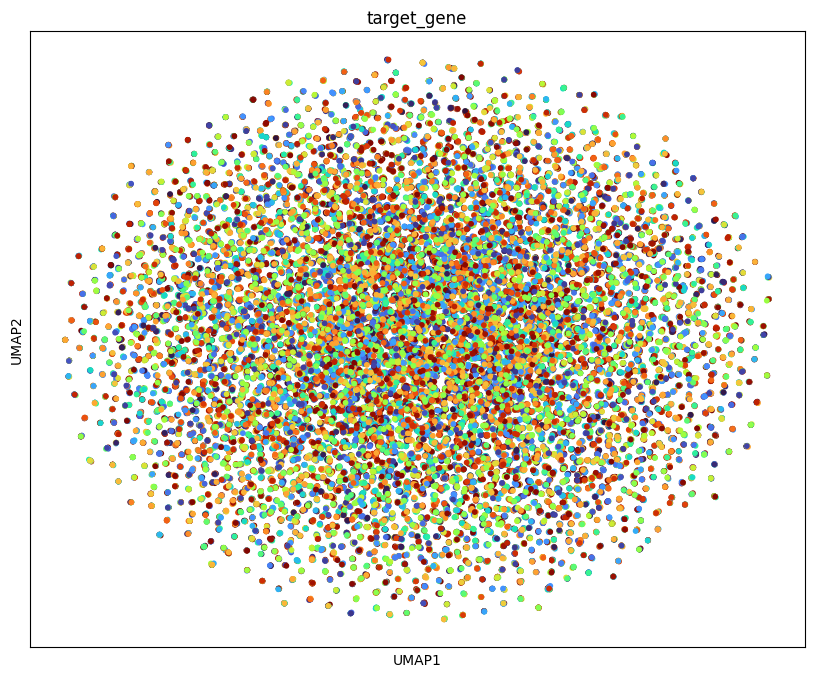

In [ ]:
import matplotlib.colors as mcolors

pred_adata.obs['target_gene'] = pred_adata.obs['target_gene'].astype('category')
num_categories = len(pred_adata.obs['target_gene'].cat.categories)

# We use 'turbo' here, but 'jet' or 'nipy_spectral' are also good for high contrast
rgba_colors = plt.cm.turbo(np.linspace(0, 1, num_categories))
hex_palette = [mcolors.to_hex(c) for c in rgba_colors]
fig, ax = plt.subplots(figsize=(10, 8))
sc.pl.umap( #tsne
    pred_adata, 
    color='target_gene', 
    palette=hex_palette,
    size=70,
    # Optional: Turn off the legend if it blocks the view
    legend_loc='none',
    ax = ax
)

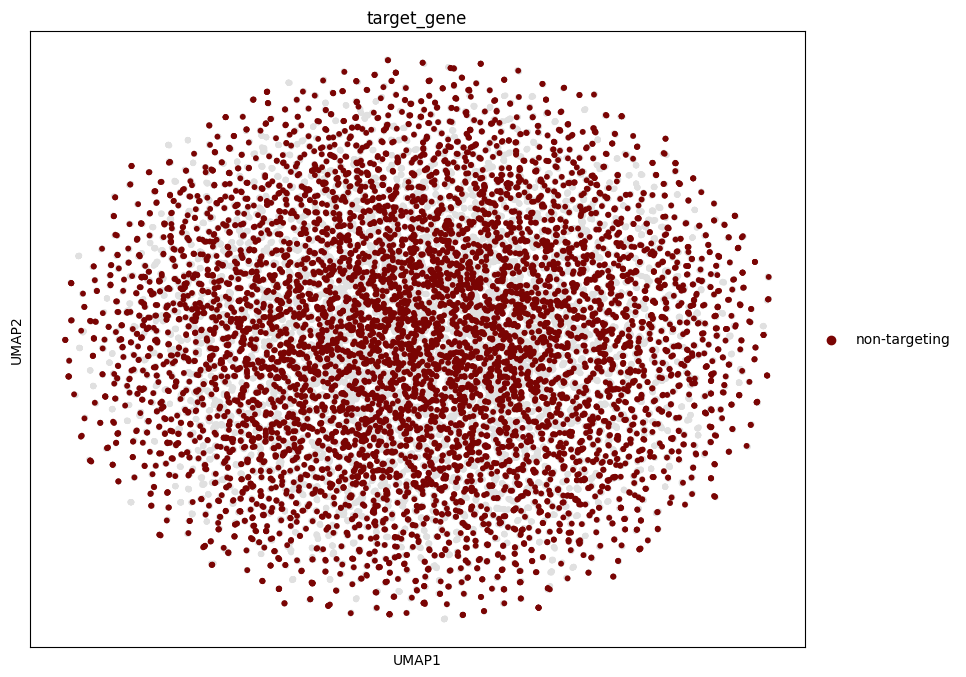

In [ ]:
# Replace 'MY_GENE_NAME' with the specific gene you want to see
gene_to_show = 'non-targeting'

fig, ax = plt.subplots(figsize=(10, 8))
sc.pl.umap(
    pred_adata, 
    color='target_gene', 
    groups=gene_to_show,        # This highlights ONLY this value
    size=70,
    na_color='#e0e0e0',         # Sets the background color (light grey)
    na_in_legend=False,          # Removes the 'NA' entry from the legend
    ax = ax
)

In [ ]:
from scores import MAE_error
from scores import corr_error

MAE_error(real_adata, pred_adata)

{'KIF1B': np.float32(0.026835687), 'HMGN1': np.float32(0.028006231), 'non-targeting': np.float32(0.0), 'IGF2R': np.float32(0.025407583), 'TET1': np.float32(0.030315451), 'NCK2': np.float32(0.026437791), 'TSC22D4': np.float32(0.02830008), 'MED13': np.float32(0.03476134), 'STAG2': np.float32(0.04620415), 'HIRA': np.float32(0.027715538), 'USP22': np.float32(0.030090682), 'TGFBR2': np.float32(0.041492447), 'CAMSAP2': np.float32(0.029298354), 'ATP1B1': np.float32(0.027150111), 'KLF10': np.float32(0.029554483), 'SRC': np.float32(0.026671454), 'WFS1': np.float32(0.027733637), 'KDM2B': np.float32(0.031607073), 'CAST': np.float32(0.029385284), 'KAT2A': np.float32(0.05199576), 'KDR': np.float32(0.027848577), 'NDUFB4': np.float32(0.032997355), 'STX4': np.float32(0.031030215), 'MTA1': np.float32(0.03328969), 'PTPN1': np.float32(0.026961027), 'MED12': np.float32(0.032938376), 'NISCH': np.float32(0.028654963), 'SMARCA5': np.float32(0.056429897), 'HMGB2': np.float32(0.030154828), 'CREG1': np.float32(

In [ ]:
from scores import corr_error

corr_error(real_adata, pred_adata)

{'non-targeting': np.float32(1.0), 'HIRA': np.float32(-0.0011583329), 'TADA1': np.float32(-0.0026259278), 'TMSB4X': np.float32(-0.0013547151), 'PRCP': np.float32(-0.0010144216)}
=====
average over all the perturbations: 0.19876931607723236


In [ ]:
from scores import RobustDES

des_calculator = RobustDES(lfc_threshold=0.5, alpha=0.05)

assert set(real_adata.obs['target_gene'].unique()) == set(pred_adata.obs['target_gene'].unique()), "perturbations do not match"

perts = [pert for pert in real_adata.obs['target_gene'].unique() if pert != 'non-targeting']
scores = {}
for pert in perts:
    scores[pert] = des_calculator.calculate_precision_score(real_adata, pred_adata, 'target_gene', pert, 'non-targeting')
    print(f'score: {scores[pert]}')
    print('---------------------')
global_score = sum(scores.values())/len(scores)
print(f'average score: {global_score}')

pert KIF1B - n_true = 1, n_pred = 723
True
score: 0.0013831258644345348
---------------------
pert HMGN1 - n_true = 4, n_pred = 750
True
score: 0.0013333333333155556
---------------------
pert IGF2R - n_true = 4, n_pred = 691
False
score: 0.0
---------------------
pert TET1 - n_true = 23, n_pred = 729
True
score: 0.0013717421124640364
---------------------
pert NCK2 - n_true = 1, n_pred = 709
False
score: 0.0
---------------------
pert TSC22D4 - n_true = 2, n_pred = 755
False
score: 0.0
---------------------
pert MED13 - n_true = 81, n_pred = 743
True
score: 0.005383580080681244
---------------------
pert STAG2 - n_true = 307, n_pred = 778
True
score: 0.011568123393167505
---------------------
pert HIRA - n_true = 14, n_pred = 684
False
score: 0.0
---------------------
pert USP22 - n_true = 24, n_pred = 734
True
score: 0.004087193460434779
---------------------
pert TGFBR2 - n_true = 145, n_pred = 779
False
score: 0.007702182284881872
---------------------
pert CAMSAP2 - n_true = 2, n_

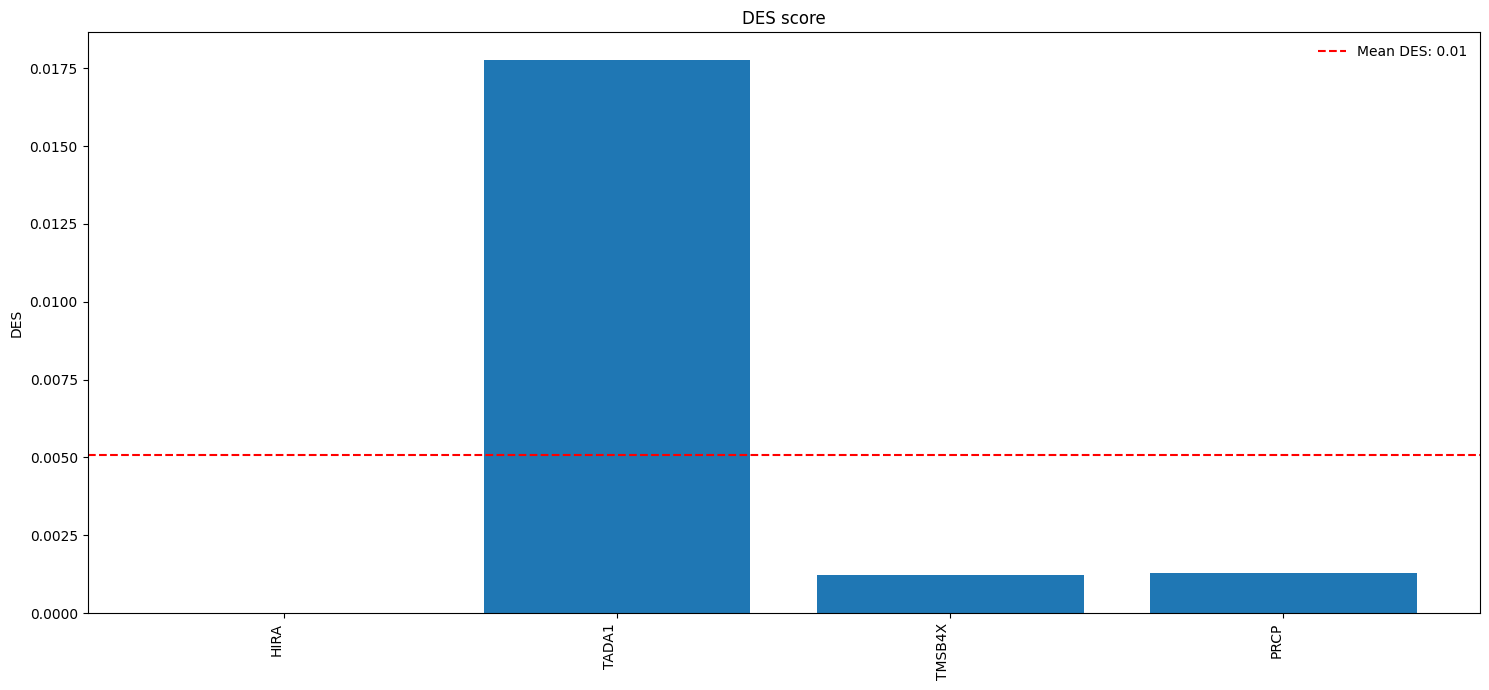

In [ ]:
values = list(scores.values())

mean_score = sum(values) / len(values)  # Or use statistics.mean(values)

plt.figure(figsize=(15, 7))
bars = plt.bar(perts, values)#, color='steelblue', alpha=0.7)
plt.xticks(rotation=90, ha='right')  # Vertical labels like your plot
plt.axhline(y=mean_score, color='red', linestyle='--', label=f'Mean DES: {global_score:.2f}')
plt.ylabel('DES')
plt.title('DES score')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

100%|██████████| 21/21 [00:11<00:00,  1.88it/s]


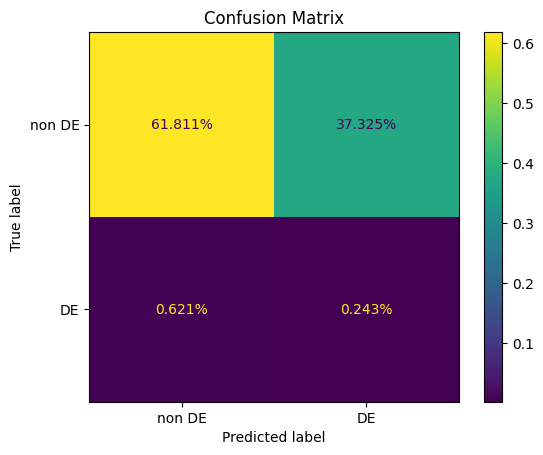

array([[0.6181109 , 0.37324889],
       [0.00620753, 0.00243268]])

In [ ]:
des_calculator.DES_confusion_matrix(perts,real_adata,pred_adata,'target_gene', 'non-targeting')

In [ ]:
pred_adata.write('results/pred_adata.h5ad')
real_adata.write('results/real_adata.h5ad')

/localscratch/31748299.michele.calabro/ipykernel_3069402/1463717486.py:5: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  real_adata.obs['dataset'] = 'Ground Truth'
/localscratch/31748299.michele.calabro/ipykernel_3069402/1463717486.py:9: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_combined = real_adata[real_adata.obs['target_gene']=='non-targeting'].concatenate(
/scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1730: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  out = concat(
/scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See htt

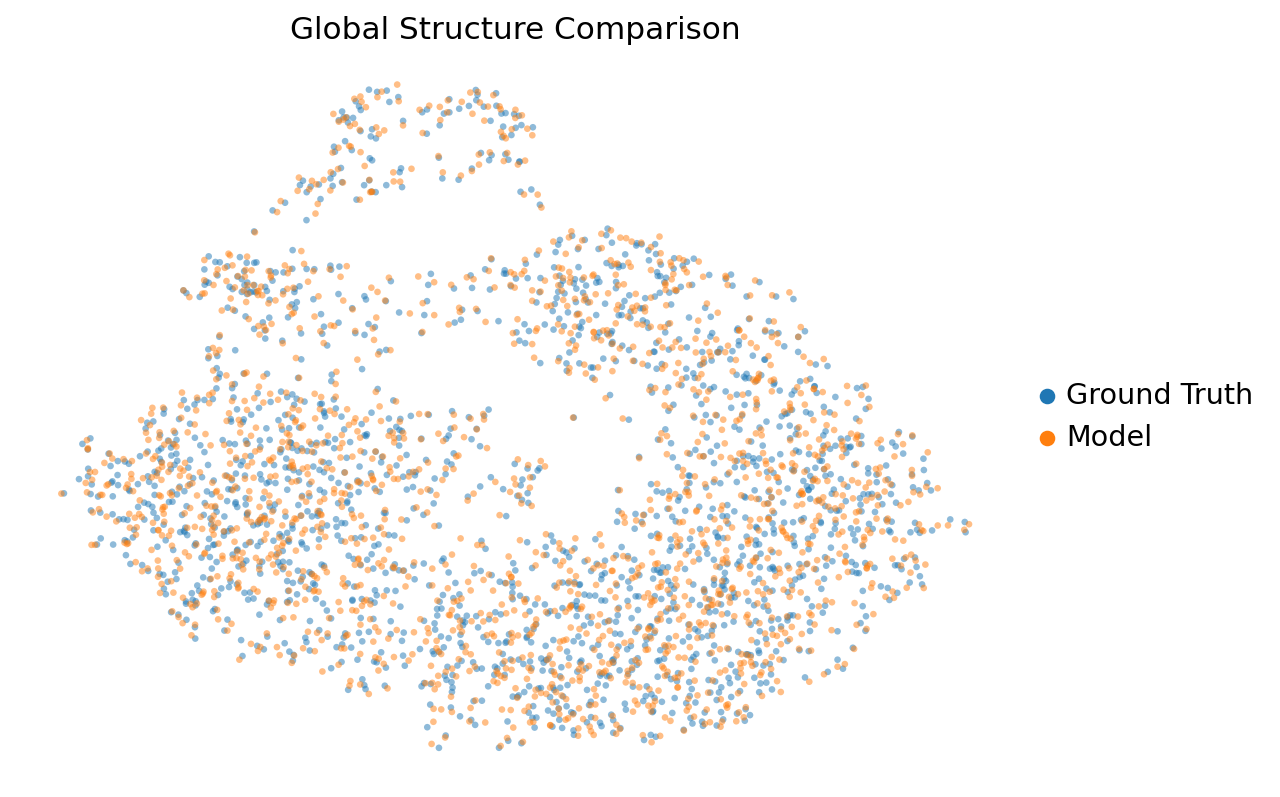

In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt

# 1. Label your datasets
real_adata.obs['dataset'] = 'Ground Truth'
pred_adata.obs['dataset'] = 'Model'

# 2. Concatenate them
adata_combined = real_adata[real_adata.obs['target_gene']=='non-targeting'].concatenate(
    pred_adata[pred_adata.obs['target_gene']=='non-targeting'],
    batch_key='source',
    index_unique='-'
)

# 3. Compute embeddings
sc.pp.pca(adata_combined)
sc.pp.neighbors(adata_combined)
sc.tl.umap(adata_combined)   # <-- FIXED

# 4. Plot
sc.set_figure_params(figsize=(8, 6))
sc.pl.umap(
    adata_combined,
    color=['dataset'],
    alpha=0.5,
    title="Global Structure Comparison",
    frameon = False,
    #save = "umap.pdf"
)


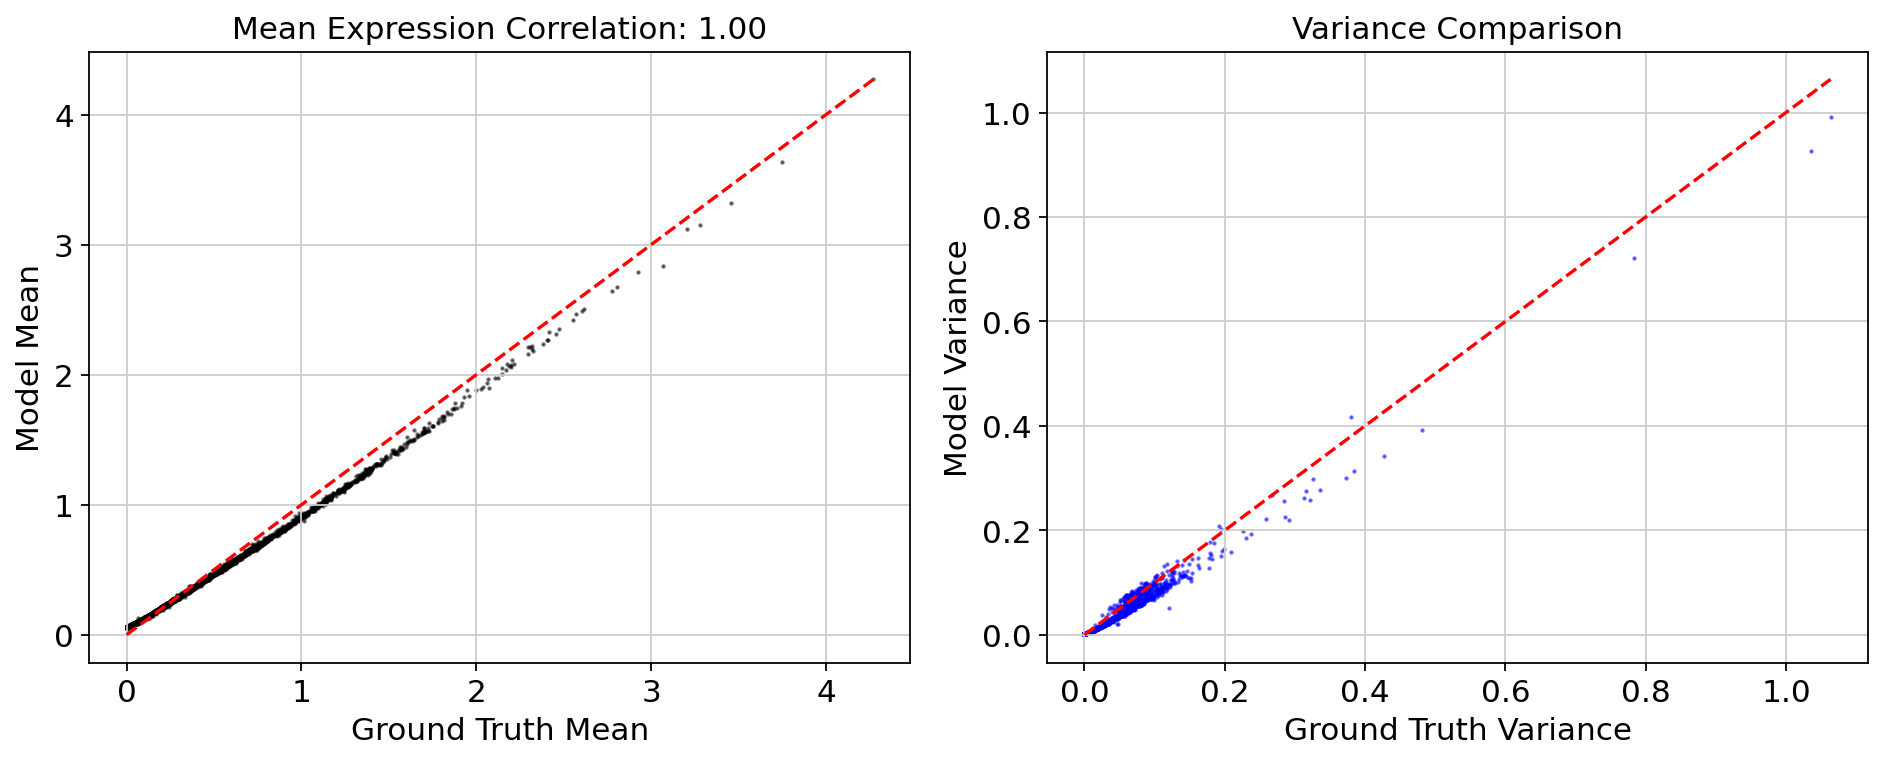

In [ ]:
import numpy as np
import seaborn as sns

# Helper function to get mean expression per gene
def get_gene_metrics(adata):
    # Handle sparse matrices if necessary
    if hasattr(adata.X, "toarray"):
        X = adata.X.toarray()
    else:
        X = adata.X
    
    mean_exp = np.mean(X, axis=0)
    var_exp = np.var(X, axis=0)
    return mean_exp, var_exp

gt_mean, gt_var = get_gene_metrics(real_adata)
model_mean, model_var = get_gene_metrics(pred_adata)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Mean Expression
ax[0].scatter(gt_mean, model_mean, s=1, alpha=0.5, c='k')
ax[0].plot([0, max(gt_mean)], [0, max(gt_mean)], 'r--') # Diagonal
ax[0].set_xlabel("Ground Truth Mean")
ax[0].set_ylabel("Model Mean")
ax[0].set_title(f"Mean Expression Correlation: {np.corrcoef(gt_mean, model_mean)[0,1]:.2f}")

# Plot 2: Variance (Dispersion)
ax[1].scatter(gt_var, model_var, s=1, alpha=0.5, c='b')
ax[1].plot([0, max(gt_var)], [0, max(gt_var)], 'r--') # Diagonal
ax[1].set_xlabel("Ground Truth Variance")
ax[1].set_ylabel("Model Variance")
ax[1].set_title("Variance Comparison")

plt.tight_layout()
plt.show()

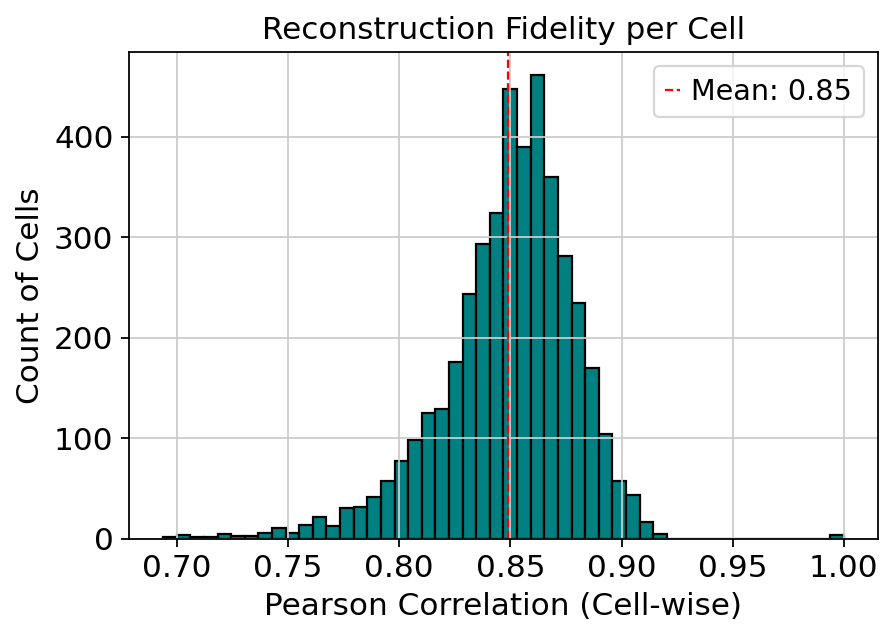

In [ ]:
from scipy.stats import pearsonr

correlations = []
n_cells = pred_adata.shape[0]

# Convert to dense once if memory allows, or iterate carefully
X_gt = real_adata.X if not hasattr(real_adata.X, "toarray") else real_adata.X.toarray()
X_model = pred_adata.X if not hasattr(pred_adata.X, "toarray") else pred_adata.X.toarray()

for i in range(n_cells):
    # Calculate correlation for cell i
    corr, _ = pearsonr(X_gt[i], X_model[i])
    correlations.append(corr)

# Plot Histogram of Correlations
plt.figure(figsize=(6, 4))
plt.hist(correlations, bins=50, color='teal', edgecolor='black')
plt.xlabel("Pearson Correlation (Cell-wise)")
plt.ylabel("Count of Cells")
plt.title("Reconstruction Fidelity per Cell")
plt.axvline(np.mean(correlations), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(correlations):.2f}')
plt.legend()
plt.show()

***

### **Generative model - please work**

In [ ]:
def generate_adata(perts_x_ncells, model, gene_to_idx, var_names):
    prediction_list = []
    obs_gene_list = []

    # for each perturbation....
    for pert in perts_x_ncells.keys():
        if pert != "non-targeting":
            print(pert)

            # how many cells are in the real data and I have to generate with the generative model?
            n_cells = perts_x_ncells[pert]

            # index corresponding to the pert
            ko_gene_idx = gene_to_idx[pert]

            # generate n_cell perturbed cells
            for j in range(n_cells):
                _, predicted_full_gex = model.generative_prediction(ko_gene_idx)
                predicted_full_gex = predicted_full_gex.reshape(1,-1).detach().cpu()
                prediction_list.append(predicted_full_gex.numpy()) 
                obs_gene_list.append(pert)

    # Stack all (1, N) vectors → shape (total_cells, N)
    X = np.vstack(prediction_list)

    # Build obs dataframe
    obs = pd.DataFrame({
        "target_gene": obs_gene_list
    })

    # Build var dataframe (gene names)
    var = pd.DataFrame(index=var_names)   # length N list of gene names

    pred_adata = ad.AnnData(X=X, obs=obs, var=var)
    return pred_adata

In [ ]:
counts = real_adata.obs['target_gene'].value_counts()
counts = counts[counts >= 200]

# Remove 'non-targeting'
gene_counts_dict = counts.drop('non-targeting').to_dict()
del counts

pred_adata2 = generate_adata(gene_counts_dict, model, gene_to_idx, real_adata.var_names)
pred_adata2


In [ ]:
# Filter for non-targeting
ntc_adata = real_adata[real_adata.obs["target_gene"] == "non-targeting"]

# Append the non-targeting controls to the example anndata if they're missing
if "non-targeting" not in pred_adata.obs["target_gene"].unique():
    assert np.all(pred_adata.var_names.values == ntc_adata.var_names.values), (
        "Gene-Names are out of order or unequal"
    )
    pred_adata = ad.concat(
        [
            pred_adata,
            ntc_adata,
        ]
    )
del ntc_adata
pred_adata

AnnData object with n_obs × n_vars = 11638 × 3406
    obs: 'target_gene'

In [ ]:
real_adata

View of AnnData object with n_obs × n_vars = 9027 × 18020
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

***